# Addressed random generation

Before launching Jupyter, create the project environment with `./create_environment.sh`, activate it with `conda activate tensor_dslab`, and select that environment's Python kernel.

This CPU-only example uses TensorCore's public addressed-randomness objects. A counter-based generator is a pure mapping from a seed, role key, complete address, and raw-word ordinal to deterministic words. It has no mutable stream position and does not use Torch's global RNG state.

In [1]:
from typing import final
import warnings

import matplotlib.pyplot as plt
import torch
import tensor_core
from tensor_core import (
    CounterRng,
    PoissonDistribution,
    ProbabilityKernel,
    RngAddress,
    RngElements,
    Threefry4x32,
)

from tensor_dslab import SampleAxis

device = torch.device("cpu")
print(f"TensorCore addressed API exports={len(tensor_core.__all__)}; Torch {torch.__version__}; device={device}")

TensorCore addressed API exports=30; Torch 2.13.0; device=cpu


## One delayed-crosstalk frontier

`parent_counts` is a private integer execution frontier over a `SampleAxis`. It is not the public floating-point `Charge` TensorField, although its descendants contribute to that eventual product.

In [2]:
global_rng_before = torch.random.get_rng_state().clone()
parent_counts = torch.tensor([3, 1, 4, 0, 2, 0], dtype=torch.int64, device=device)
sample_axis = SampleAxis(start=0, step=2_000, count=parent_counts.numel())
parent_counts

tensor([3, 1, 4, 0, 2, 0])

## Immutable element identities

Canonical `RngElements` use row-major local identities. Only public shape/device metadata is consumed below; the displayed integers come from the caller-owned tensor used to construct a second equivalent snapshot, never from TensorCore's private storage.

In [3]:
elements = RngElements.from_shape(tuple(parent_counts.shape), device=device)
caller_owned_ids = torch.arange(parent_counts.numel(), dtype=torch.int64, device=device)
snapshot_elements = RngElements.from_tensor(caller_owned_ids)
assert snapshot_elements.shape == elements.shape
print(f"element_shape={elements.shape}; device={elements.device}")
caller_owned_ids

element_shape=(6,); device=cpu


tensor([0, 1, 2, 3, 4, 5])

## Package role and generation address

The role key below comes from the precise private TensorDSLab implementation module so this example cannot duplicate its namespace or stream number. That module is unsupported implementation detail: users do not configure production role keys, and importing it here creates no public compatibility promise.

The root reserves a generation domain. Selecting one generation produces the atomic address required by `CounterRng.words(...)` and the tensor-valued Poisson draw.

In [4]:
from tensor_dslab.readout.runtime.keys import DELAYED_CROSSTALK_RETAINED_RNG_KEY

maximum_generations = 3
generation_index = 1
root_address = RngAddress.root(
    key=DELAYED_CROSSTALK_RETAINED_RNG_KEY,
    elements=elements,
    shape=(maximum_generations,),
    quantum=0,
)
generation_address = root_address.select(generation_index)
print(
    f"root_shape={root_address.shape}; selected_shape={generation_address.shape}; "
    f"element_shape={generation_address.element_shape}; device={generation_address.device}; "
    f"complete={generation_address.is_complete}"
)

root_shape=(3,); selected_shape=(); element_shape=(6,); device=cpu; complete=True


## Raw words

Threefry maps each complete address plus ordinal to a word. The public `CounterRng.words(...)` surface exposes those results without reproducing Threefry rounds, constants, packing, or private permutation mechanics. Rows correspond to the caller-owned destination IDs shown above.

In [5]:
rng: CounterRng = Threefry4x32(seed=11)
raw_ordinals = (0, 1, 5)
word_table = rng.words(address=generation_address, ordinals=raw_ordinals)
print("columns: destination_id, address_complete, ordinal_0, ordinal_1, ordinal_5")
torch.cat(
    (
        caller_owned_ids[:, None],
        torch.full((parent_counts.numel(), 1), int(generation_address.is_complete), dtype=torch.int64),
        word_table,
    ),
    dim=1,
)

columns: destination_id, address_complete, ordinal_0, ordinal_1, ordinal_5


tensor([[         0,          1, 2797997635,  824971383, 2664289792],
        [         1,          1, 4088737205, 1368442777, 2447842931],
        [         2,          1, 2089915739,  554687307, 1754253657],
        [         3,          1, 2879796595,  792299228, 1074058161],
        [         4,          1,   44239873, 4247263261, 2596258793],
        [         5,          1, 2294399230, 1607253094, 3446694057]])

## Causal delay kernel and retained destination means

The semantic kernel represents nonnegative causal displacements. TensorDSLab deterministically collapses all retained parent/category contributions into one destination-rate tensor: `lambda[d] = sum_s parent_counts[s] * mean_offspring * probability[d-s]`. Negative and out-of-window displacements contribute nothing.

In [6]:
@final
class DemoDelayKernel(ProbabilityKernel[tuple[type[SampleAxis]]]):
    __slots__ = ()

    def _require(self) -> None:
        if self.axis_types != (SampleAxis,):
            raise ValueError("demo delay kernel must use SampleAxis")


delay_kernel = DemoDelayKernel(
    tensor=torch.tensor([0.55, 0.30, 0.10], dtype=torch.float64, device=device),
    axis_types=(SampleAxis,),
)
mean_offspring = 0.4
destination_rate = torch.zeros_like(parent_counts, dtype=torch.float64)
for destination in range(parent_counts.numel()):
    for source in range(destination + 1):
        displacement = destination - source
        if displacement < delay_kernel.shape[0]:
            destination_rate[destination] += (
                parent_counts[source].to(torch.float64)
                * mean_offspring
                * delay_kernel.tensor[displacement]
            )
destination_rate

tensor([0.6600, 0.5800, 1.1200, 0.5200, 0.6000, 0.2400], dtype=torch.float64)

## One collapsed tensor Poisson draw

One tensor-valued `PoissonDistribution` draws the complete destination frontier. This is Poisson splitting/superposition in rate-first form; it is not a source-total Poisson followed by a Multinomial allocation.

In [7]:
law = PoissonDistribution(mean=destination_rate)
sampled_avalanches = law.draw(rng=rng, address=generation_address)
repeated_avalanches = law.draw(
    rng=Threefry4x32(seed=11),
    address=generation_address,
)
assert torch.equal(sampled_avalanches, repeated_avalanches)
sampled_avalanches

tensor([1, 2, 1, 1, 0, 0])

## Chunk invariance without renumbering

The two chunks are slices of the original `RngElements`, so their identities and root capacity are retained. Rebuilding generation roots on those slices and concatenating their results reproduces the full draw exactly.

In [8]:
chunk_bounds = ((0, 2), (2, parent_counts.numel()))
chunk_draws = []
for start, stop in chunk_bounds:
    chunk_elements = elements.slice(0, start, stop)
    chunk_address = RngAddress.root(
        key=DELAYED_CROSSTALK_RETAINED_RNG_KEY,
        elements=chunk_elements,
        shape=(maximum_generations,),
        quantum=0,
    ).select(generation_index)
    chunk_draws.append(
        PoissonDistribution(mean=destination_rate[start:stop]).draw(
            rng=Threefry4x32(seed=11),
            address=chunk_address,
        )
    )
chunked_avalanches = torch.cat(chunk_draws)
assert torch.equal(chunked_avalanches, sampled_avalanches)
chunked_avalanches

tensor([1, 2, 1, 1, 0, 0])

## Global RNG isolation and visualization

All random results above are addressed explicitly. Torch's global RNG state remains unchanged. The four compact panels show the input frontier, represented kernel, deterministic retained rate, and sampled destination counts.

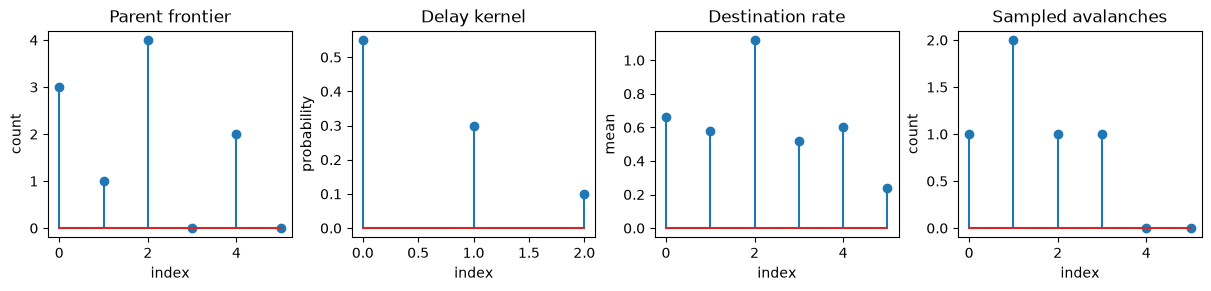

In [9]:
assert torch.equal(torch.random.get_rng_state(), global_rng_before)

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), constrained_layout=True)
panels = (
    (parent_counts, "Parent frontier", "count"),
    (delay_kernel.tensor, "Delay kernel", "probability"),
    (destination_rate, "Destination rate", "mean"),
    (sampled_avalanches, "Sampled avalanches", "count"),
)
for axis, (values, title, ylabel) in zip(axes, panels, strict=True):
    axis.stem(range(values.numel()), values.to(device="cpu").tolist())
    axis.set(title=title, xlabel="index", ylabel=ylabel)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    plt.show()

The exact words and samples are reproducible for this seed, private role key, address schema, and dependency version. This notebook teaches the selected mechanism; it does not create a TensorDSLab RNG facade, a configurable production-key surface, or a second scientific implementation.